In [1]:
%pip install torch torchvision matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import glob

In [3]:
# Same transform as training/validation
infer_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

from torchvision import models

class SSLBackbone(nn.Module):
    """Backbone (ResNet50 encoder) used during training."""
    def __init__(self):
        super().__init__()
        base = models.resnet50(weights=None)  # same as training
        self.encoder = nn.Sequential(*list(base.children())[:-1])  # remove final fc
        self.out_dim = 2048

    def forward(self, x):
        x = self.encoder(x)   # [B, 2048, 1, 1]
        x = x.flatten(1)      # [B, 2048]
        return x

class SSLClassifier(nn.Module):
    def __init__(self, backbone: SSLBackbone):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(self.backbone.out_dim, 1)  # binary clf

    def forward(self, x):
        feats = self.backbone(x)
        logits = self.head(feats)
        return logits.squeeze(1)  # [B]
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(
    r"C:\Users\user\Documents\Computer vision\ssl\ssl_yolo_defect.pth",
    map_location=device,
)

backbone = SSLBackbone()
model_infer = SSLClassifier(backbone)

model_infer.load_state_dict(ckpt)  # ckpt is the state_dict
model_infer.to(device)
model_infer.eval()    

SSLClassifier(
  (backbone): SSLBackbone(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)

In [4]:
def predict_one(img_path, model, device):
    model.eval()
    image = Image.open(img_path).convert("RGB")
    image = infer_transform(image)
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logit = model(image)
        prob_normal = torch.sigmoid(logit).item()  # probability of class 1 (normal)
    prob_defect = 1.0 - prob_normal

    if prob_normal >= 0.5:
        pred_label = 1  # normal
    else:
        pred_label = 0  # defect

    return pred_label, prob_normal, prob_defect

Found 40 images in C:\Users\user\Documents\Computer vision\data\test\images
[1] frame_0014_jpg.rf.37c183e37a975ec10d3374e4c86131db.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


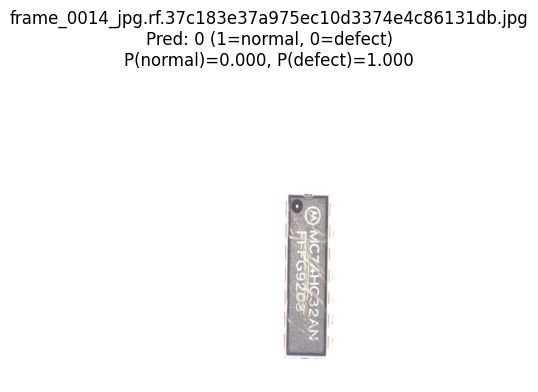

[2] frame_0018_jpg.rf.553926ee70e91f5d47023d26701f4afe.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


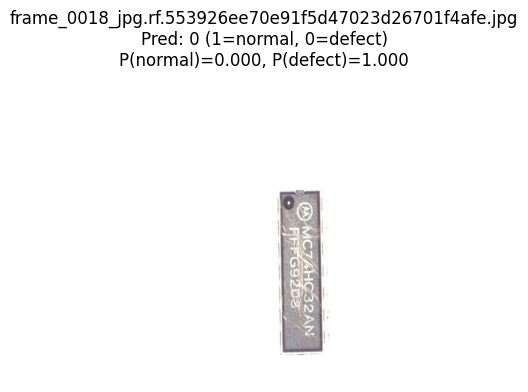

[3] frame_0019_jpg.rf.bafe95bbcebf1425087ed7732f5e861e.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


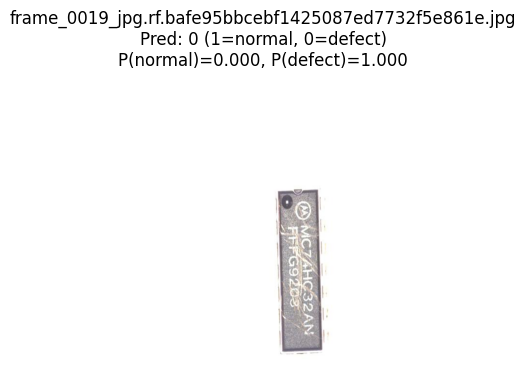

[4] frame_0024_jpg.rf.8f6d325aed70e45d32f9144235bb1668.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


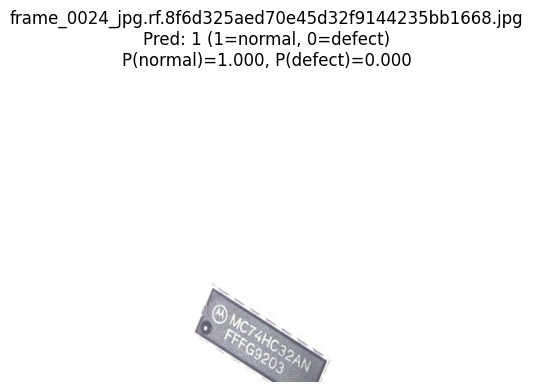

[5] frame_0031_jpg.rf.d1a72920bcf109f76e1ecb96c4fa5c1e.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


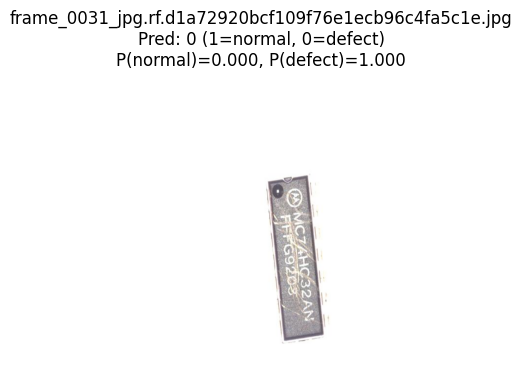

[6] frame_0037_jpg.rf.5f37e33e42a4ee3af3feb6882e896c76.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


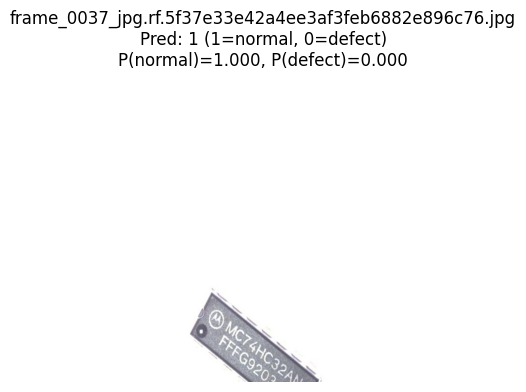

[7] frame_0045_jpg.rf.c568e43f9b428ac6828b46812a51aadd.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


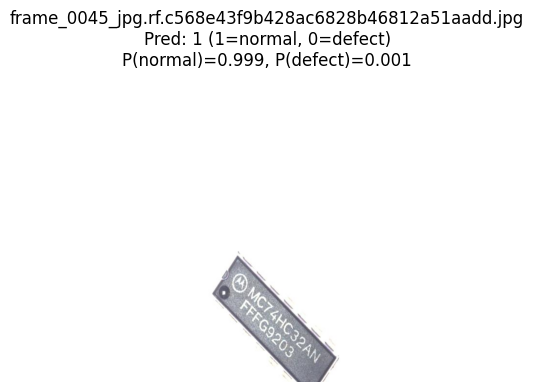

[8] frame_0052_jpg.rf.22726835fdae75d428b77083806323e3.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


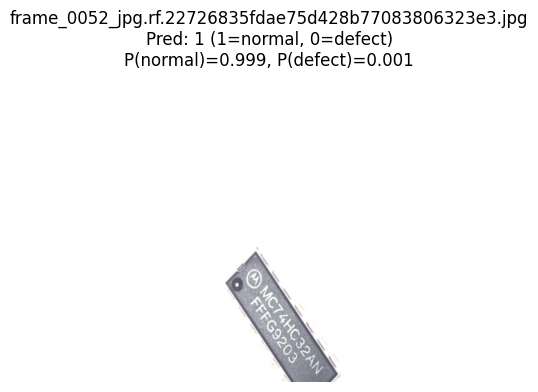

[9] frame_0052_jpg.rf.5166a4d76c1ff2d78778fe770e01ccc0.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


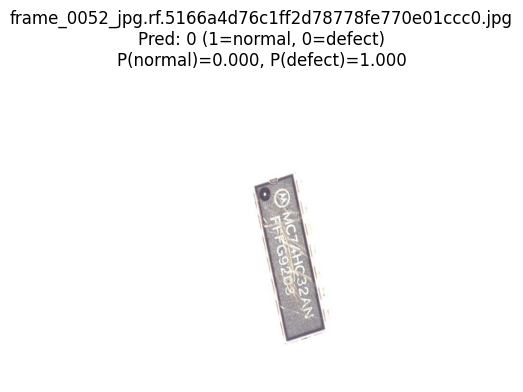

[10] frame_0056_jpg.rf.d412dc647ccbdc3facc0e6629f7451a2.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


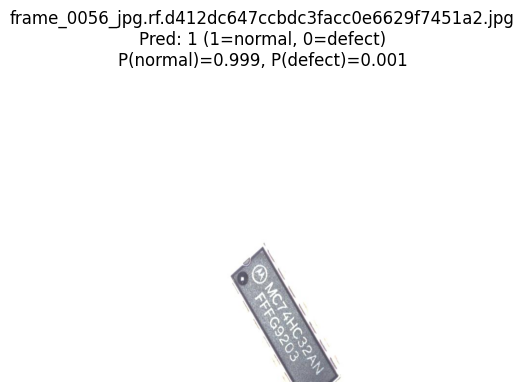

[11] frame_0058_jpg.rf.db32e054b92d2be7efbe9d440a958c3b.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


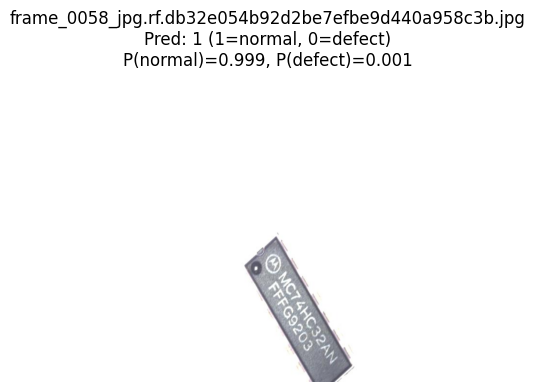

[12] frame_0064_jpg.rf.e18c4426efebb1e414f830814ef66389.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


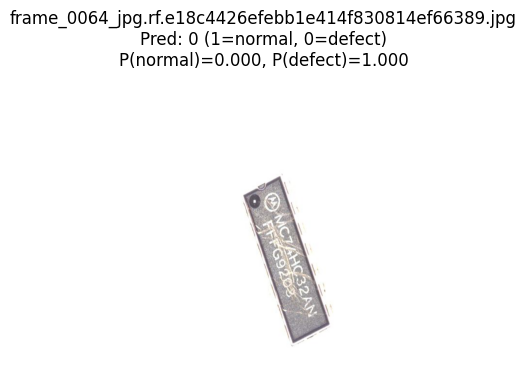

[13] frame_0068_jpg.rf.e6bf51222b5bbd378d881f4563430fab.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


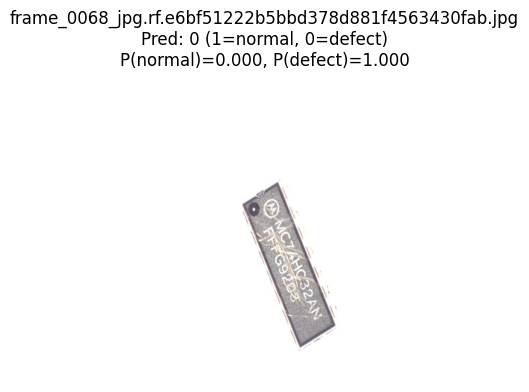

[14] frame_0075_jpg.rf.e2a4cf6d6176830f2a23568441d0821b.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.998, P(defect)=0.002


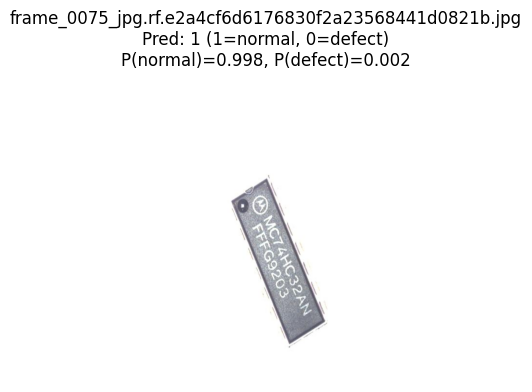

[15] frame_0085_jpg.rf.7e40b6e6dafe96c3570941289f27766c.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


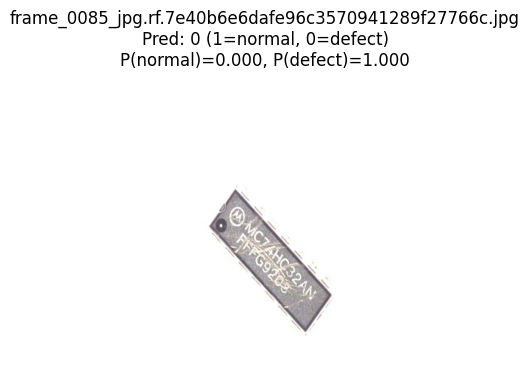

[16] frame_0086_jpg.rf.c2f7ce01c1b1ea19a2645e58d43ff64a.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


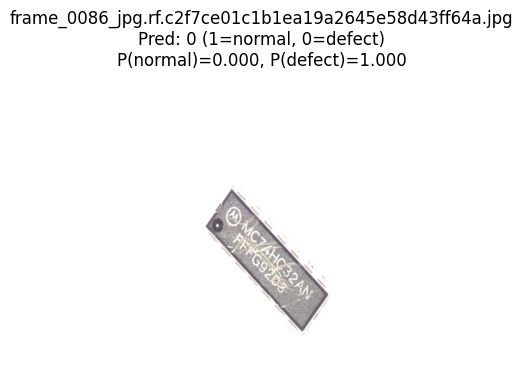

[17] frame_0091_jpg.rf.05a0897a96399580e60081ab66ef519b.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.998, P(defect)=0.002


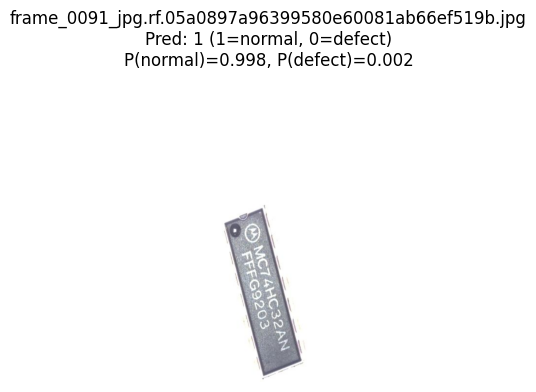

[18] frame_0150_jpg.rf.a0c1019b21269994f5745eedb800b7d3.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


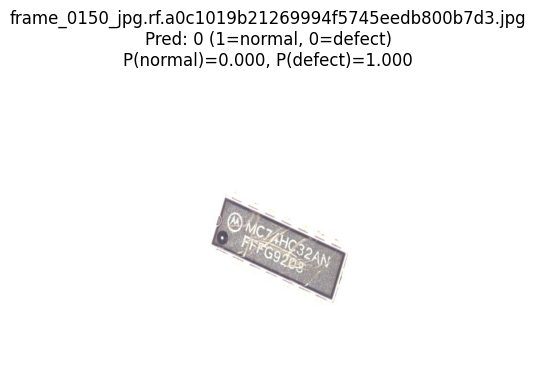

[19] frame_0151_jpg.rf.0af99166bbd592de50fdc0b2eb2a2e64.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


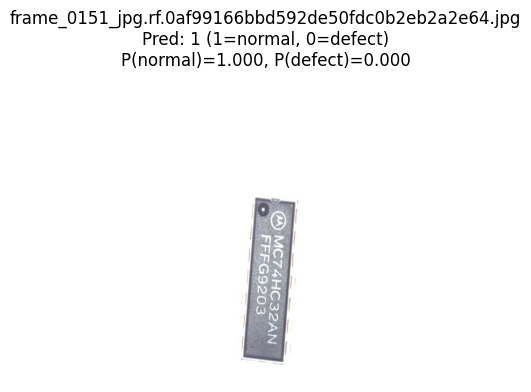

[20] frame_0153_jpg.rf.244eb3fa9b2510a8277f7ef6e59a7b80.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


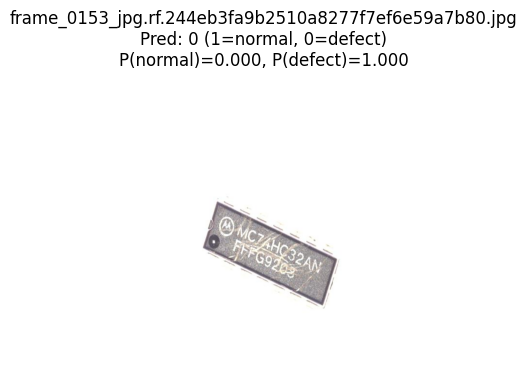

[21] frame_0155_jpg.rf.04d0855368c471194828211a4823e99b.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


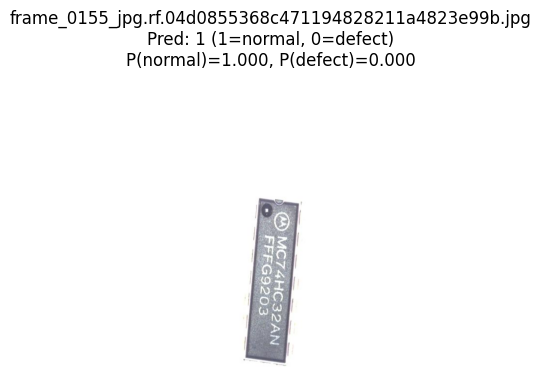

[22] frame_0155_jpg.rf.05dd8d8c734f639bcefcfcb8ea686d7d.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


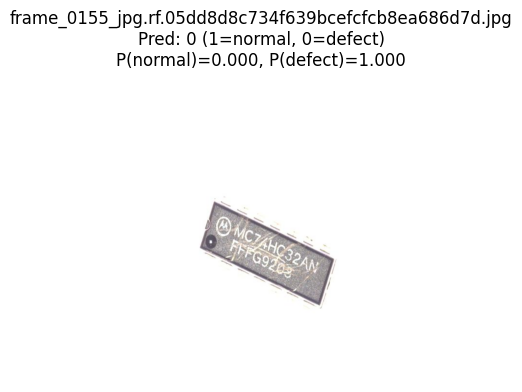

[23] frame_0161_jpg.rf.cf2f4086ef416aa1d189a9e707c4c410.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


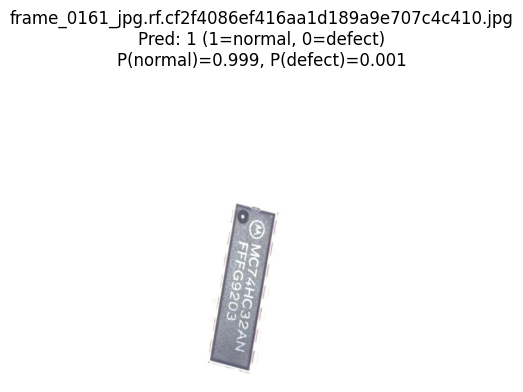

[24] frame_0163_jpg.rf.12b129cf6352ebdb82bffb020e4f9f8a.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


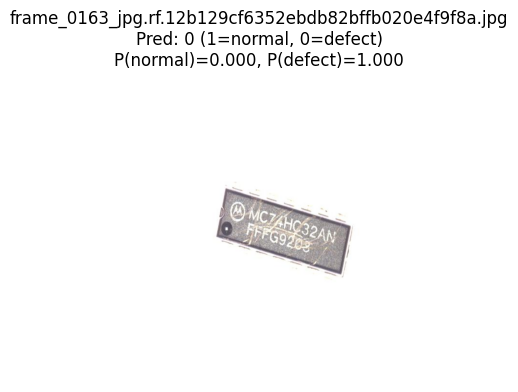

[25] frame_0169_jpg.rf.b90d1684944bd4660e8503cdf048ea12.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.001, P(defect)=0.999


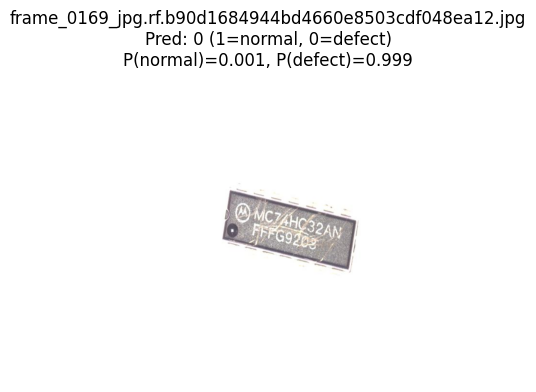

[26] frame_0171_jpg.rf.02fe709e49a6cf38af5884724994f84c.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.001, P(defect)=0.999


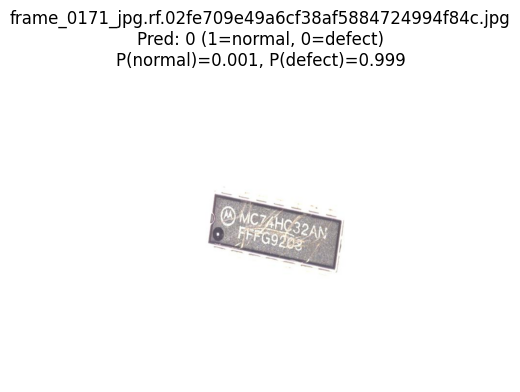

[27] frame_0172_jpg.rf.315527f2158f694601335e2a004beea1.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


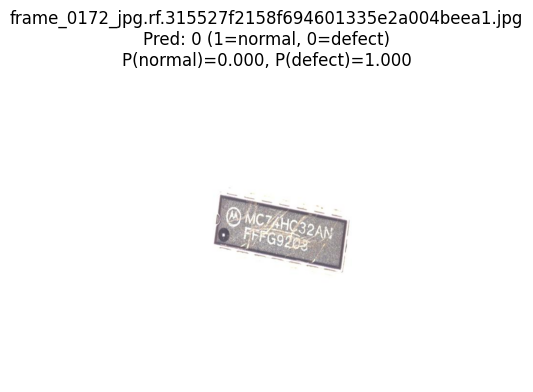

[28] frame_0178_jpg.rf.4b96c33a3b379978ce1c0309d3673f40.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


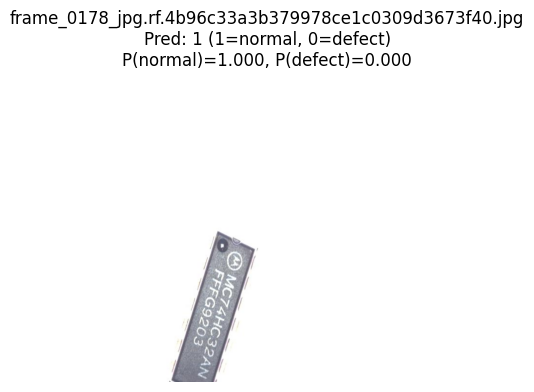

[29] frame_0184_jpg.rf.2eb9dc0723ae7b2919d11645fcc33e56.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


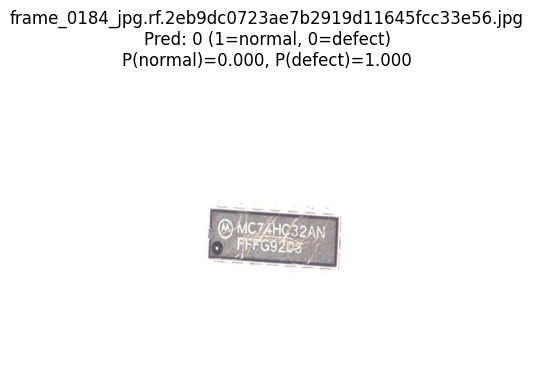

[30] frame_0186_jpg.rf.075b2c92545f6fcea915749100ee08a3.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.001, P(defect)=0.999


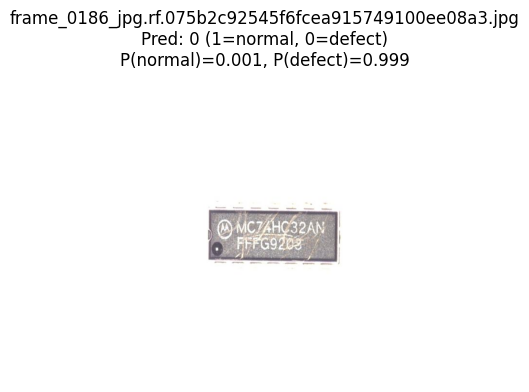

[31] frame_0189_jpg.rf.a9b4780ddb9befa1a52e5f9d93726306.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.007, P(defect)=0.993


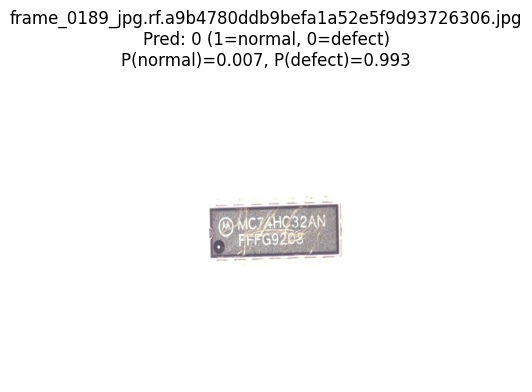

[32] frame_0205_jpg.rf.441cee0e5fb928a3f31bfdfcc4471efd.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


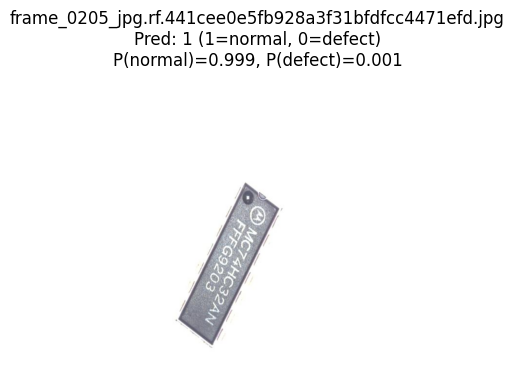

[33] frame_0208_jpg.rf.86ca5439a5e9d0232e5dcd89f001ed61.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.998, P(defect)=0.002


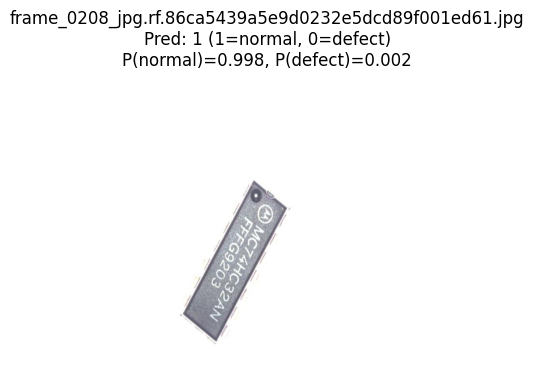

[34] frame_0211_jpg.rf.b60c12c21dbfc3c60a89e72552f332f2.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


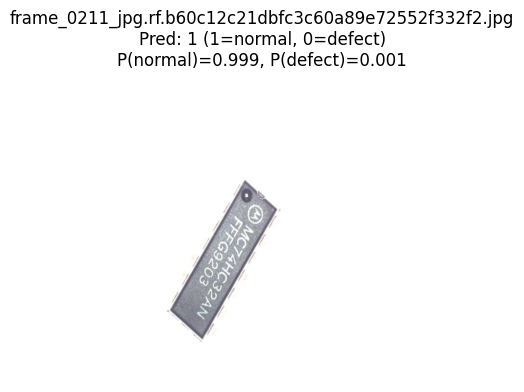

[35] frame_0212_jpg.rf.9562f2bbaab16fc56b97c6624749ddd3.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


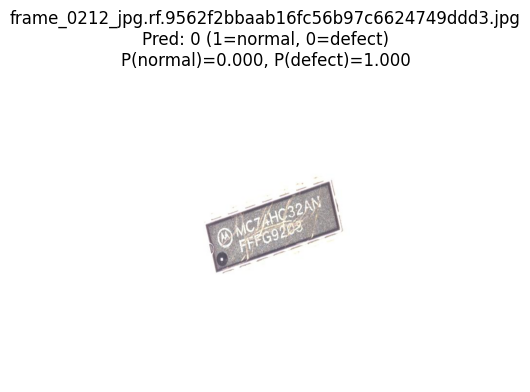

[36] frame_0224_jpg.rf.6fa5246878740dd89d93a571928f4d8e.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=0.999, P(defect)=0.001


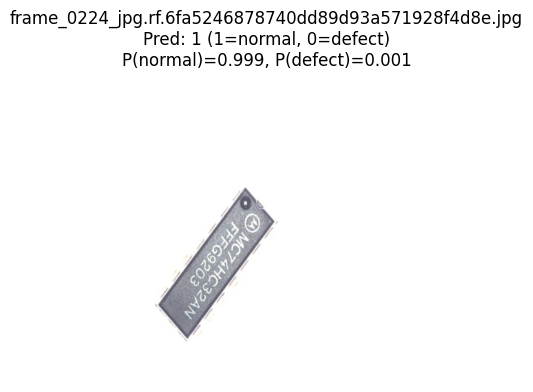

[37] frame_0228_jpg.rf.4ba8bb49deb859c6039a301b94860ff4.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


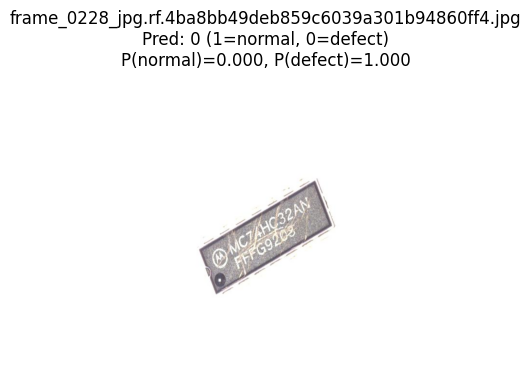

[38] frame_0229_jpg.rf.e9e8ca63a657a7e3209143d267a21501.jpg -> Predicted label: 1 (1=normal, 0=defect), P(normal)=1.000, P(defect)=0.000


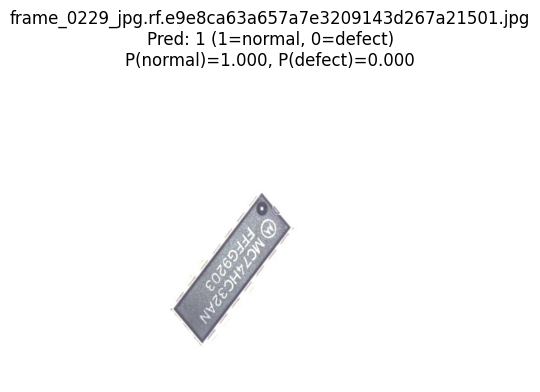

[39] frame_0232_jpg.rf.059b71e3f298e3627812dcd2cb8c5101.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


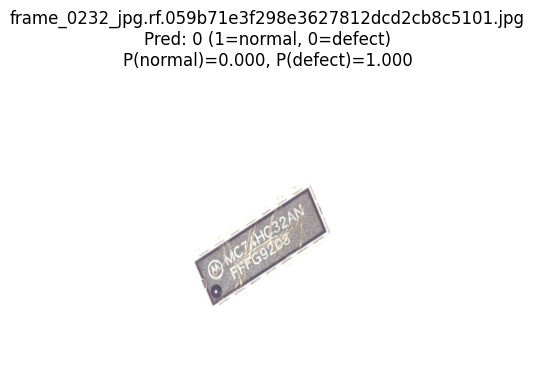

[40] frame_0234_jpg.rf.69e3ec2ce398a0edb6a91d9ab81bee8e.jpg -> Predicted label: 0 (1=normal, 0=defect), P(normal)=0.000, P(defect)=1.000


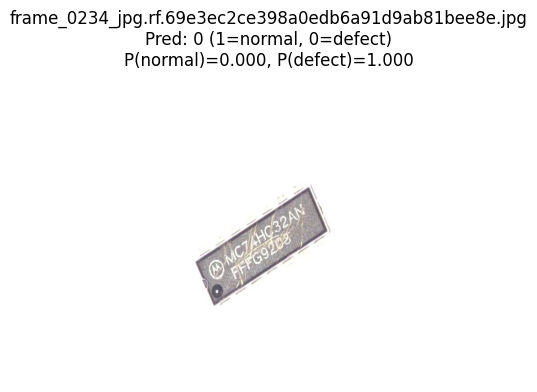

In [5]:
test_images_dir = r"C:\Users\user\Documents\Computer vision\data\test\images"

image_paths = sorted(
    glob.glob(os.path.join(test_images_dir, "*.jpg"))
    + glob.glob(os.path.join(test_images_dir, "*.jpeg"))
    + glob.glob(os.path.join(test_images_dir, "*.png"))
    + glob.glob(os.path.join(test_images_dir, "*.bmp"))
)

print(f"Found {len(image_paths)} images in {test_images_dir}")

# Set a maximum number of images to display to avoid too many plots
max_images_to_show = None

for idx, img_path in enumerate(image_paths):
    if max_images_to_show is not None and idx >= max_images_to_show:
        print(f"Reached max_images_to_show={max_images_to_show}, stopping.")
        break

    pred_label, p_normal, p_defect = predict_one(img_path, model_infer, device)
    print(f"[{idx+1}] {os.path.basename(img_path)} -> Predicted label: {pred_label} (1=normal, 0=defect), "
          f"P(normal)={p_normal:.3f}, P(defect)={p_defect:.3f}")

    img = Image.open(img_path).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{os.path.basename(img_path)}\nPred: {pred_label} (1=normal, 0=defect)\n"
              f"P(normal)={p_normal:.3f}, P(defect)={p_defect:.3f}")
    plt.show()